In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as la
from matplotlib.collections import LineCollection

from tqdm import tqdm

from koala.pointsets import uniform
from koala.voronization import generate_lattice
from koala.lattice import cut_boundaries
from koala.graph_utils import make_dual, lloyd_relaxation, remove_trailing_edges
from koala import plotting as kplt
import matplotlib
from matplotlib.colors import TwoSlopeNorm

matplotlib.rcParams.update({'font.size': 11, 'text.usetex': True, 'font.family': 'serif', 'font.serif': ['Computer Modern']})

In [3]:
def qwz_hamiltonian(lattice, u_vals, h_field = 0):
    if isinstance(u_vals, (int, float, complex)):
        u_vals = np.array([u_vals] * lattice.n_vertices)

    a_site_part = np.diag(u_vals+0j)
    b_site_part = -np.diag(u_vals+0j)

    ab_link_part = np.zeros((lattice.n_vertices, lattice.n_vertices), dtype = complex)
    ba_link_part = np.zeros((lattice.n_vertices, lattice.n_vertices), dtype = complex)

    p1 = lattice.vertices.positions[lattice.edges.indices[:, 0]]
    p2 = lattice.vertices.positions[lattice.edges.indices[:, 1]]   
    average_y = 0.5*(p1[:,1] + p2[:,1])
    change_x = p2[:,0] - p1[:,0]
    phases = -h_field * average_y * change_x * lattice.n_plaquettes

    for edge_index in range(lattice.n_edges):

        field_phase = 1j*phases[edge_index]*2*np.pi
        
        edge = lattice.edges.indices[edge_index]

        vec = lattice.edges.vectors[edge_index]
        angle = np.angle(vec[0] + 1j * vec[1])

        ab_link_part[edge[0], edge[1]] = 0.5j*np.exp(-1j*angle + field_phase)
        ba_link_part[edge[0], edge[1]] = 0.5j*np.exp(1j*angle + field_phase)
        a_site_part[edge[0], edge[1]] = 0.5*np.exp(field_phase)
        b_site_part[edge[0], edge[1]] = -0.5*np.exp(field_phase)

        # add conjugates
        ba_link_part[edge[1], edge[0]] = -0.5j*np.exp(1j*angle - field_phase)
        ab_link_part[edge[1], edge[0]] = -0.5j*np.exp(-1j*angle - field_phase)
        a_site_part[edge[1], edge[0]] = 0.5*np.exp(-field_phase)
        b_site_part[edge[1], edge[0]] = -0.5*np.exp(-field_phase)

    return np.block([
        [a_site_part, ab_link_part],
        [ba_link_part, b_site_part]
    ])

def step_marker(l, P):
    positions = l.vertices.positions 
    step_x = (positions[:,0]-0.5) > 0
    step_y = (positions[:,1]-0.5) > 0
    step_x = np.kron(np.ones(2), step_x)
    step_y = np.kron(np.ones(2), step_y)
    step_marker = (((P*step_x) @ (P*step_y) - (P*step_y) @ (P*step_y))@ P).diagonal().imag
    return step_marker[:l.n_vertices] + step_marker[l.n_vertices:]


In [4]:
points = uniform(1000)
lattice = lloyd_relaxation(generate_lattice(points))
lattice_strip = remove_trailing_edges(cut_boundaries(lattice, [True, True]))


In [5]:
h_pbc = qwz_hamiltonian(lattice, -0.5)
e_pbc, v_pbc = la.eigh(h_pbc)
proj_pbc = v_pbc * (e_pbc<0) @ v_pbc.T.conj()
marker_pbc = step_marker(lattice, proj_pbc)

h_strip = qwz_hamiltonian(lattice_strip, -0.5)
e_strip, v_strip = la.eigh(h_strip)
proj_strip = v_strip * (e_strip<0) @ v_strip.T.conj()
marker_strip = step_marker(lattice_strip, proj_strip)

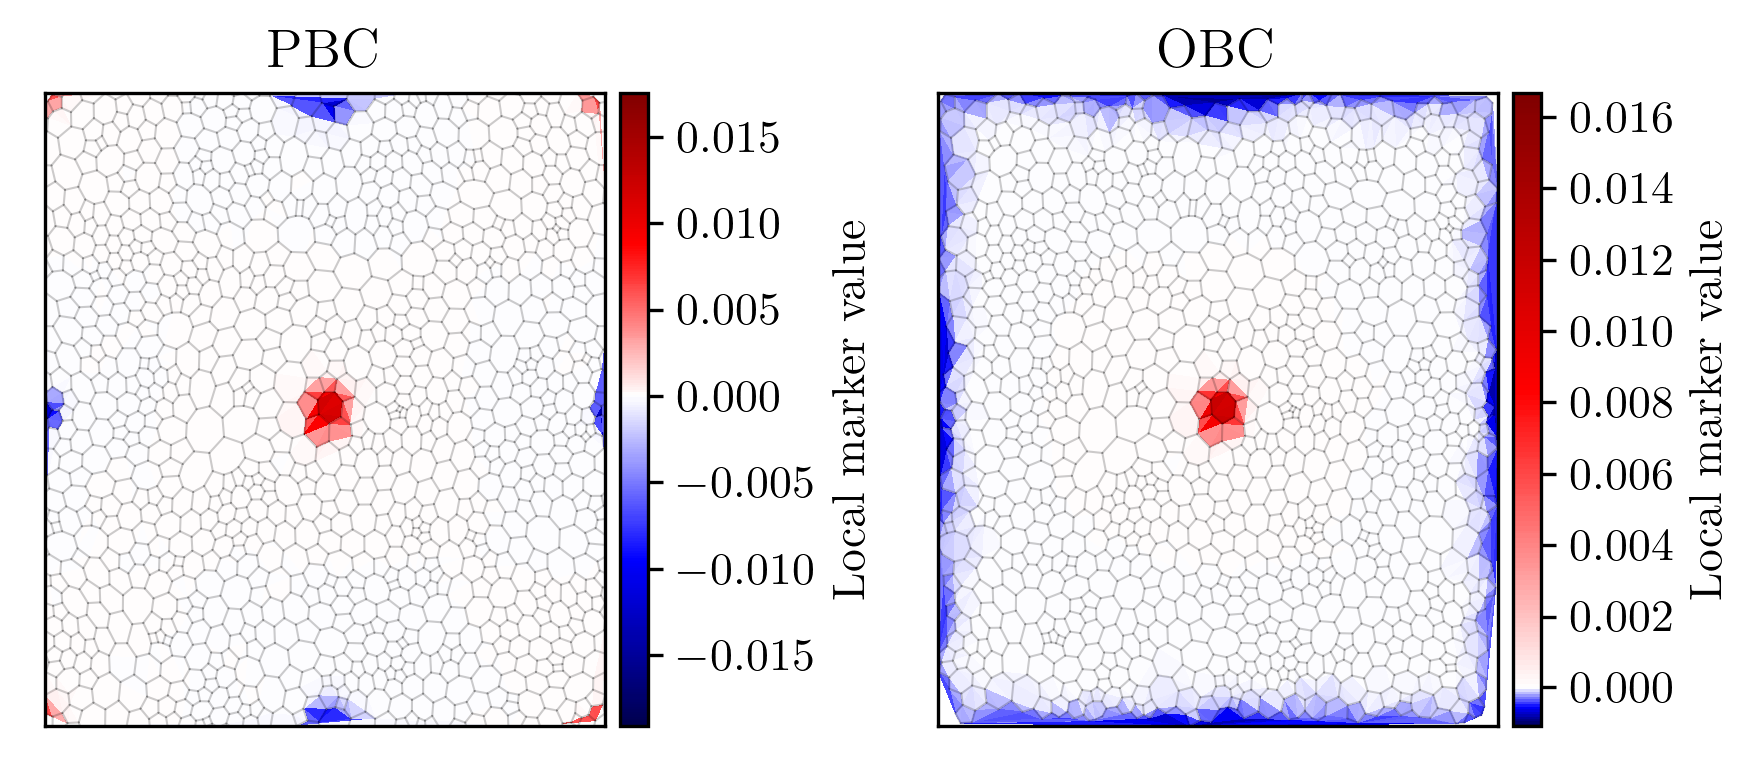

In [6]:
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1,2, figsize = (6,2.7), dpi = 300, tight_layout=True)

ax[0].set_title('PBC')
ax[1].set_title('OBC')

# ax[0].set_aspect('equal')
# ax[1].set_aspect('equal')

ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])


for n, l in enumerate([lattice, lattice_strip]):
    kplt.plot_edges(l, ax = ax[n], color = 'k', linewidth = 0.5, alpha = 0.2)

    x_vals = l.vertices.positions[:,0]
    y_vals = l.vertices.positions[:,1]

    z_vals = [marker_pbc, marker_strip][n]
    divnorm = colors.TwoSlopeNorm(vmin=z_vals.min() , vcenter=0, vmax=z_vals.max())
    pcm = ax[n].tripcolor(x_vals, y_vals, z_vals, norm= divnorm, cmap= 'seismic', rasterized=True) 

    divider = make_axes_locatable(ax[n])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(pcm, cax=cax, orientation='vertical', label = 'Local marker value')

# plt.savefig('kitaev_marker_proper.pdf', bbox_inches='tight')



0.9999994727226809
0.9999995277908292


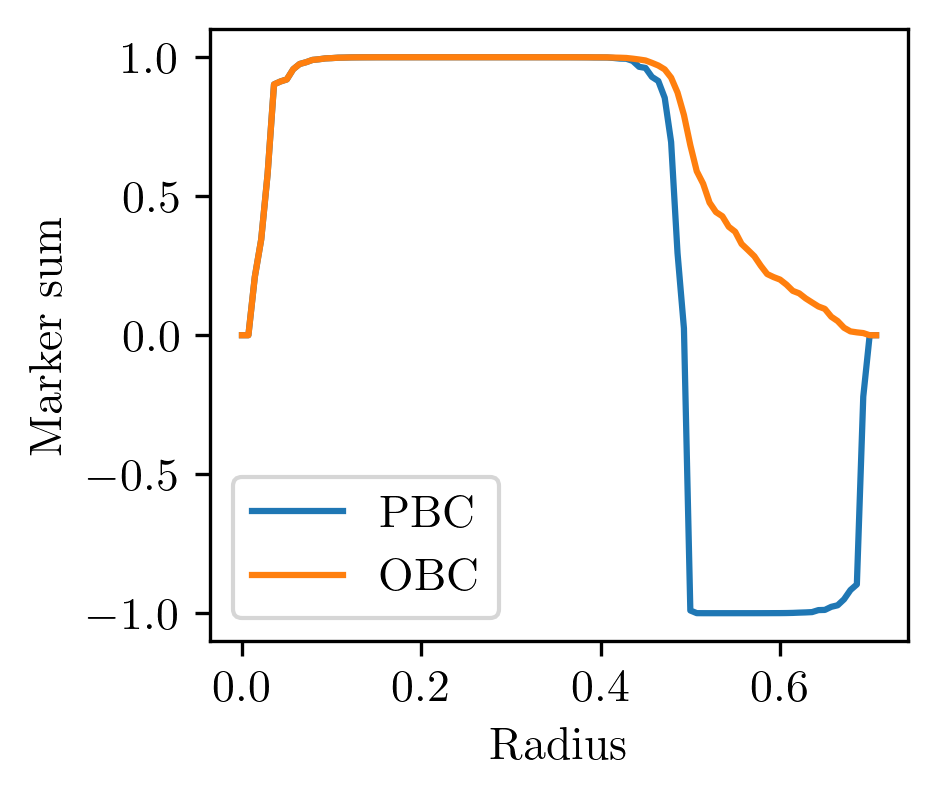

In [14]:
fig, ax = plt.subplots( figsize = (3,2.7), dpi = 300)

labels = ['PBC', 'OBC']

for n, l in enumerate([lattice, lattice_strip]):
    label = labels[n]
    positions = l.vertices.positions
    distance_from_center = np.sqrt((positions[:,0]-0.5)**2 + (positions[:,1]-0.5)**2)

    circle_sizes = np.linspace(0, np.sqrt(1/2), 100)
    indices_in_circle = [ np.argwhere(distance_from_center < r) for r in circle_sizes]

    indices = indices_in_circle[n]
    values = [4*np.pi*np.sum([marker_pbc, marker_strip][n][indices]) for indices in indices_in_circle]
    print(np.array(values).max())
    plt.plot(circle_sizes, values, label = label)

plt.legend( loc='lower left')
plt.xlabel('Radius')
plt.ylabel('Marker sum')

plt.savefig('kitaev_marker_proper_sum.pdf', bbox_inches='tight')

In [15]:
1-0.999999

1.0000000000287557e-06